In [ ]:
!unzip -o intern.zip
#extracting and cleaning
from pathlib import Path
import re
!pip install pypdf
from pypdf import PdfReader
input_fol=Path("intern/corpus")
output_fol=Path("extracted_text")
for pdf_path in input_fol.rglob("*.pdf"):
  relative_path=pdf_path.relative_to(input_fol)
  txt_path=output_fol/relative_path.with_suffix(".txt")
  txt_path.parent.mkdir(parents=True, exist_ok=True)
  try:
    reader=PdfReader(str(pdf_path))
    text_parts=[]
    for page in reader.pages:
      text_parts.append(page.extract_text())
      extracted_text="\n".join(text_parts).strip()
      extracted_text= re.sub(r'-\s*\n\s*','',extracted_text)
      extracted_text=re.sub(r'\n{3,}','\n\n',extracted_text)
    with open(txt_path, "w", encoding="utf-8") as f:
      f.write(extracted_text)
    print(f"Saved: {txt_path}")
  except Exception as e:
    print(f"Error processing {pdf_path} -> {e}")
#chunking and adding metadata
import json
input_fol=Path("extracted_text")
output_fol=Path("paragraph_chunks")
output_fol.mkdir(parents=True,exist_ok=True)
max_chars=1200
min_chars=800
overlaps=120
def split_long_text(text,max_char=max_chars,overlap=overlaps):
  chunks=[]
  start=0
  while start<len(text):
    end=min(start+max_chars,len(text))
    chunk=text[start:end].strip()
    if chunk:
      chunks.append(chunk)
    if end == len(text):
      break
    start=max(0,end-overlap)
  return chunks
for txt_path in input_fol.rglob("*.txt"):
  rel_path=txt_path.relative_to(input_fol)
  output_path=output_fol/rel_path.with_suffix("")
  output_path.mkdir(parents=True,exist_ok=True)
  text=txt_path.read_text(encoding="utf-8").strip()
  paragraphs=[p.strip() for p in text.split("\n\n") if p.strip()]
  chunks=[]
  for para in paragraphs:
    if len(para)<=max_chars:
      chunks.append(para)
    else:
      chunks.extend(split_long_text(para))
  merged_chunks=[]
  for chunk in chunks:
    if merged_chunks and len(chunk)<min_chars:
      candidate=merged_chunks[-1]+"\n\n"+chunk
      if len(candidate)<=max_chars:
        merged_chunks[-1]=candidate
      else:
        merged_chunks.append(chunk)
    else:
      merged_chunks.append(chunk)
  for i, chunk in enumerate(merged_chunks,1):
    chunkfile=output_path/f"chunk_{i}.txt"
    metafile=output_path/f"chunk_{i}.json"
    chunkfile.write_text(chunk,encoding="utf-8")
    metadata={
        "source_file": str(rel_path),
        "chunk_id":i,
        "character_count":len(chunk),
        "paragraph_split": "\n\n" in chunk
    }
    metafile.write_text(json.dumps(metadata,indent=2),encoding="utf-8")
    print(f"saved: {chunkfile} ({len(chunk)} chars)")
#embeddings
!pip install -q -U sentence-transformers qdrant-client

from pathlib import Path
import json
import shutil

from sentence_transformers import SentenceTransformer
from qdrant_client import QdrantClient
from qdrant_client.models import VectorParams, Distance, PointStruct
#Loading embedding model
print("Loading embedding model...")

import torch
from sentence_transformers import SentenceTransformer

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", device)

model = SentenceTransformer(
    "intfloat/multilingual-e5-large-instruct",
    device=device
)

print("Model loaded successfully!")
#creating Qdrant database
db_path = "/content/qdrant_db"

if Path(db_path).exists():
    shutil.rmtree(db_path)

client = QdrantClient(path=db_path)

collection_name = "logic_corpus"

if client.collection_exists(collection_name):
    client.delete_collection(collection_name)

client.create_collection(
    collection_name=collection_name,
    vectors_config=VectorParams(
        size=1024,
        distance=Distance.COSINE
    )
)
#Read chunks
chunk_root = Path("/content/paragraph_chunks")

txt_files = sorted(chunk_root.rglob("chunk_*.txt"))

print(f"Found {len(txt_files)} chunk files.")

texts = []
payloads = []

for txt_file in txt_files:

    text = txt_file.read_text(
        encoding="utf-8"
    ).strip()

    if not text:
        continue

    json_file = txt_file.with_suffix(".json")

    metadata = {}

    if json_file.exists():

        with open(json_file, "r", encoding="utf-8") as f:

            metadata = json.load(f)

    texts.append("passage: " + text)

    payloads.append({

        "text": text,

        "source_file": metadata.get("source_file", ""),

        "chunk_id": metadata.get("chunk_id", 0),

        "character_count": metadata.get(
            "character_count",
            len(text)
        ),

        "paragraph_split": metadata.get(
            "paragraph_split",
            False
        )

    })

print(f"Prepared {len(texts)} chunks for embedding.")
#Generate embeddings
print("Generating embeddings...")

embeddings = model.encode(

    texts,

    batch_size=32,

    show_progress_bar=True,

    normalize_embeddings=True,

    convert_to_numpy=True

)

print("Embeddings generated!")
#converting into qdrant points
points = []

for idx in range(len(payloads)):

    points.append(

        PointStruct(

            id=idx,

            vector=embeddings[idx].tolist(),

            payload=payloads[idx]

        )

    )

print(f"Prepared {len(points)} Qdrant points.")
#uploading
UPLOAD_BATCH = 100

print("Uploading to Qdrant...")

for i in range(0, len(points), UPLOAD_BATCH):

    client.upsert(

        collection_name=collection_name,

        points=points[i:i+UPLOAD_BATCH]

    )

    print(f"Uploaded {min(i+UPLOAD_BATCH,len(points))}/{len(points)}")

print("="*60)
print("Embedding completed successfully!")
print(f"Total chunks embedded : {len(points)}")
print(f"Collection            : {collection_name}")
print("="*60)
client.close()

Archive:  intern.zip
   creating: intern/
   creating: intern/corpus/
   creating: intern/corpus/cp/
  inflating: intern/corpus/cp/ca1.pdf  
  inflating: intern/corpus/cp/ca2.pdf  
  inflating: intern/corpus/cp/ca3.pdf  
   creating: intern/corpus/greek/
  inflating: intern/corpus/greek/Francis_Bacon_-_Stanford_Encylopedia.pdf  
  inflating: intern/corpus/greek/Organon-Aristotle.pdf  
  inflating: intern/corpus/greek/The-Prior-Analytics-Aristotle.pdf  
   creating: intern/corpus/nyaya/
  inflating: intern/corpus/nyaya/Nyaya-Sutras-Of-Gautama-vol.-1.pdf  
  inflating: intern/corpus/nyaya/rp on nyaya sastra.pdf  
  inflating: intern/corpus/nyaya/Tarka Sangraha.pdf  
   creating: intern/extracted_text/
Saved: extracted_text/nyaya/Nyaya-Sutras-Of-Gautama-vol.-1.txt
Saved: extracted_text/nyaya/Tarka Sangraha.txt
Saved: extracted_text/nyaya/rp on nyaya sastra.txt
Saved: extracted_text/cp/ca2.txt
Saved: extracted_text/cp/ca3.txt
Saved: extracted_text/cp/ca1.txt
Saved: extracted_text/greek/Org

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Model loaded successfully!
Found 3096 chunk files.
Prepared 3096 chunks for embedding.
Generating embeddings...


Batches:   0%|          | 0/97 [00:00<?, ?it/s]

Embeddings generated!
Prepared 3096 Qdrant points.
Uploading to Qdrant...
Uploaded 100/3096
Uploaded 200/3096
Uploaded 300/3096
Uploaded 400/3096
Uploaded 500/3096
Uploaded 600/3096
Uploaded 700/3096
Uploaded 800/3096
Uploaded 900/3096
Uploaded 1000/3096
Uploaded 1100/3096
Uploaded 1200/3096
Uploaded 1300/3096
Uploaded 1400/3096
Uploaded 1500/3096
Uploaded 1600/3096
Uploaded 1700/3096
Uploaded 1800/3096
Uploaded 1900/3096
Uploaded 2000/3096
Uploaded 2100/3096
Uploaded 2200/3096
Uploaded 2300/3096
Uploaded 2400/3096
Uploaded 2500/3096
Uploaded 2600/3096
Uploaded 2700/3096
Uploaded 2800/3096
Uploaded 2900/3096
Uploaded 3000/3096
Uploaded 3096/3096
Embedding completed successfully!
Total chunks embedded : 3096
Collection            : logic_corpus


In [ ]:
#Testing the Qdrant Retrieval
#client.close()
import torch
#loading embedding model

device = "cuda" if torch.cuda.is_available() else "cpu"

model = SentenceTransformer(
    "intfloat/multilingual-e5-large-instruct",
    device=device
)
# connecting to qdrant
client = QdrantClient(path="/content/qdrant_db")
collection_name = "logic_corpus"
# Query
query = input("Enter your question   ")
# query embedding
query_embedding = model.encode(
    "query: " + query,
    normalize_embeddings=True
).tolist()
# Search qdrant
results = client.query_points(
    collection_name=collection_name,
    query=query_embedding,
    limit=6
).points
# print retrieved chunks
print("\n")
print("="*80)
print("TOP 5 RETRIEVED CHUNKS")
print("="*80)

for i, point in enumerate(results, start=1):

    print(f"\nRank : {i}")
    print("-"*80)

    print("Similarity Score :",
          round(point.score,4))

    print("Source File :",
          point.payload.get("source_file",""))

    print("Chunk ID :",
          point.payload.get("chunk_id",""))

    print("Character Count :",
          point.payload.get("character_count",""))

    print("\nRetrieved Text:\n")

    print(point.payload["text"])

    print("\n"+"="*80)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Enter your question   what is nyaya?


TOP 5 RETRIEVED CHUNKS

Rank : 1
--------------------------------------------------------------------------------
Similarity Score : 0.8516
Source File : cp/ca1.txt
Chunk ID : 3
Character Count : 1200

Retrieved Text:

n be compared. There are three 
terms in the demonstrative inference: The Paksa, the sadhya and the hetu correspond 
to the minor term, the major term and the middle term of the Aristotelian syllogism. 
* Nikhil Dongol is a B.A.LLB. 4 th year student of Kathmandu School of Law, Nepal.
1 Jadunath Sinha, Indian Philosophy, vol. I, New Central Book Agency (P) Ltd., India, 2000, p.511.
2 Ibid, para 2.
3 Irving M. Copi, Carl Cohen & Kenneth D. McMahon, Introduction to Logic , 14 th edition., Pearson 
Education, India, 2011, p.5.
Kathmandu School of Law Review             Volume 6 Issue 1 April 2018
188
Therefore, the Nyaya demonstrative inference (prayoga) may be compared with the 
Aristotelian syllogism4.
Nyaya is one of the six orthodo

In [ ]:
# LLM generation
client.close()

!pip install -q -U transformers accelerate

import torch
from sentence_transformers import SentenceTransformer
from qdrant_client import QdrantClient
from transformers import AutoTokenizer, AutoModelForCausalLM

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# loading emedding model
print("\nLoading embedding model...")

embedding_model = SentenceTransformer(
    "intfloat/multilingual-e5-large-instruct",
    device=device
)

print("Embedding model loaded!")


# LLM
LLM_NAME = "Qwen/Qwen2.5-3B-Instruct"

print("\nLoading LLM...")

tokenizer = AutoTokenizer.from_pretrained(
    LLM_NAME
)

llm = AutoModelForCausalLM.from_pretrained(
    LLM_NAME,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    device_map="auto"
)

print("LLM loaded!")


client = QdrantClient(
    path="/content/qdrant_db"
)

collection_name = "logic_corpus"

print("\nConnected to Qdrant!")


# question
query = input(
    "\nEnter your question: "
)


# query embedding

query_embedding = embedding_model.encode(
    "query: " + query,
    normalize_embeddings=True
).tolist()

# retrieval of top n chunks
results = client.query_points(
    collection_name=collection_name,
    query=query_embedding,
    limit=6
).points


print(
    f"\nRetrieved {len(results)} chunks from Qdrant."
)

# context
context_parts = []

for i, point in enumerate(results, start=1):

    source = point.payload.get(
        "source_file",
        "Unknown source"
    )

    chunk_id = point.payload.get(
        "chunk_id",
        "Unknown"
    )

    text = point.payload.get(
        "text",
        ""
    )

    context_parts.append(
        f"""
--- Retrieved Chunk {i} ---
Source: {source}
Chunk ID: {chunk_id}
Similarity Score: {point.score:.4f}

{text}
"""
    )


context = "\n".join(context_parts)

# RAG Prompt
prompt = f"""
You are a research assistant working with a specialized
corpus of books and articles about logic and philosophy.

Answer the user's question using the retrieved context
provided below.

Instructions:
1. Use the retrieved context as the primary source.
2. Do not invent information that is not supported by the context.
3. If the context does not contain enough information,
   say that the answer is not available in the retrieved context.
4. Give a clear and concise explanation.
5. Mention the source when relevant.

Retrieved Context:

{context}

User Question:

{query}

Answer:
"""
# chat msg
messages = [

    {
        "role": "system",
        "content": (
            "You are a research assistant. "
            "Answer questions using the retrieved context. "
            "Do not hallucinate information."
        )
    },

    {
        "role": "user",
        "content": prompt
    }

]

#LLM Chat template
formatted_prompt = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

# Tokenization
inputs = tokenizer(
    formatted_prompt,
    return_tensors="pt"
)

inputs = {
    key: value.to(llm.device)
    for key, value in inputs.items()
}

#Answer generation
print("\nGenerating answer...")

with torch.no_grad():

    outputs = llm.generate(
        **inputs,
        max_new_tokens=500,
        temperature=0.2,
        do_sample=True
    )


generated_tokens = outputs[0][
    inputs["input_ids"].shape[1]:
]


# decode

answer = tokenizer.decode(
    generated_tokens,
    skip_special_tokens=True
)


# Display final ans

print("\n")
print("="*80)
print("FINAL RAG ANSWER")
print("="*80)

print(answer)

print("="*80)


# Display sources
print("\nSOURCES USED:")
print("-"*80)

for i, point in enumerate(results, start=1):

    print(
        f"{i}. "
        f"{point.payload.get('source_file', 'Unknown')} "
        f"(Chunk {point.payload.get('chunk_id', 'Unknown')}) "
        f"[Score: {point.score:.4f}]"
    )

Device: cuda
GPU: Tesla T4

Loading embedding model...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Embedding model loaded!

Loading LLM...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

LLM loaded!

Connected to Qdrant!

Enter your question: what is nyaya?

Retrieved 6 chunks from Qdrant.

Generating answer...


FINAL RAG ANSWER
Nyaya is one of the six orthodox or astika schools of Hindu philosophy. It primarily deals with the science of logic and epistemology. The Nyaya school is known for its contributions to modern Hindu thought, particularly through its methodology which has been embraced by many other Indian philosophical schools. Nyaya philosophy includes the study of valid knowledge and logical reasoning, focusing on the nature of reality and the acquisition of knowledge.

SOURCES USED:
--------------------------------------------------------------------------------
1. cp/ca1.txt (Chunk 3) [Score: 0.8516]
2. nyaya/Nyaya-Sutras-Of-Gautama-vol.-1.txt (Chunk 1305) [Score: 0.8278]
3. nyaya/Nyaya-Sutras-Of-Gautama-vol.-1.txt (Chunk 1298) [Score: 0.8235]
4. nyaya/Nyaya-Sutras-Of-Gautama-vol.-1.txt (Chunk 14) [Score: 0.8222]
5. nyaya/Nyaya-Sutras-Of-Gautama-vol.-1.txt

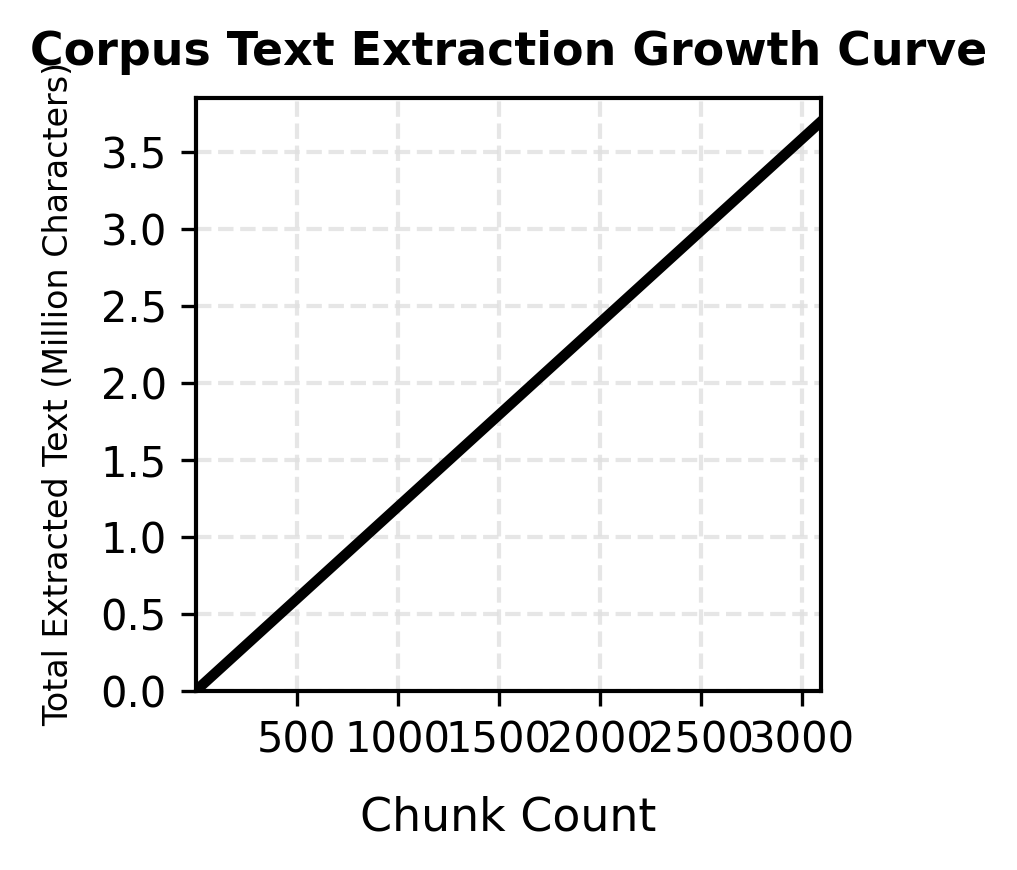

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data endpoints matching the image bounds
# Chunk 1 -> 0M characters, Chunk 3096 -> ~3.7M characters
chunks = np.array([1, 3096])
extracted_text = np.array([0.0, 3.7])

# High-DPI Figure Setup
fig, ax = plt.subplots(figsize=(3, 3), dpi=300)

# Solid black trend line matching your plot style
ax.plot(chunks, extracted_text, color='black', linewidth=2.5, zorder=3)

# Title and labels matching screenshot formatting
ax.set_title('Corpus Text Extraction Growth Curve', fontsize=11, fontweight='bold', pad=8)
ax.set_xlabel('Chunk Count', fontsize=11, labelpad=8)
ax.set_ylabel('Total Extracted Text (Million Characters)', fontsize=8, labelpad=6)

# Axis limits matching the image bounds
ax.set_xlim(1, 3096)
ax.set_ylim(0, 3.85)

# Tick marks matching screenshot layout
ax.set_xticks([500, 1000, 1500, 2000, 2500, 3000])
ax.set_yticks([0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5])

# Light gray dashed grid lines
ax.grid(True, linestyle='--', color='#e0e0e0', linewidth=1.0, alpha=0.8, zorder=1)

# Solid outer border frame
for spine in ax.spines.values():
    spine.set_linewidth(1.0)
    spine.set_color('black')

plt.tight_layout()

# Save as high-res PNG and vector PDF
plt.savefig('corpus_growth_curve_high_res.png', dpi=300, bbox_inches='tight')
plt.savefig('corpus_growth_curve_high_res.pdf', bbox_inches='tight')
plt.show()